import matplotlib
print(matplotlib.__version__)

In [1]:
!python -m pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!python -m pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --- ------------------------------------ 3.4/36.5 MB 17.2 MB/s eta 0:00:02
   ----- ---------------------------------- 5.2/36.5 MB 12.4 MB/s eta 0:00:03
   -------- ------------------------------- 7.3/36.5 MB 11.7 MB/s eta 0:00:03
   ---------- ----------------------------- 9.4/36.5 MB 11.3 MB/s eta 0:00:03
   ------------- -------------------------- 12.3/36.5 MB 11.8 MB/s eta 0:00:03
   --------------- ------------------------ 14.4/36.5 MB 11.4 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/36.5 MB 11.7 MB/s eta 0:00:02
   ---------------------- ----------------- 20.2/36.5


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sklearn

In [3]:
import sklearn
print(sklearn.__version__)

1.8.0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split

In [24]:
data = pd.read_csv ("india_housing_prices.csv")

In [25]:
data.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [27]:
data.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [28]:
data = data.dropna()

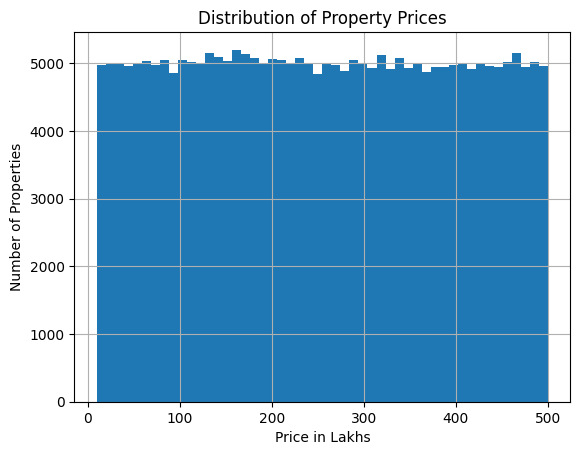

In [29]:
data['Price_in_Lakhs'].hist(bins=50)
plt.title("Distribution of Property Prices")
plt.xlabel("Price in Lakhs")
plt.ylabel("Number of Properties")
plt.show()

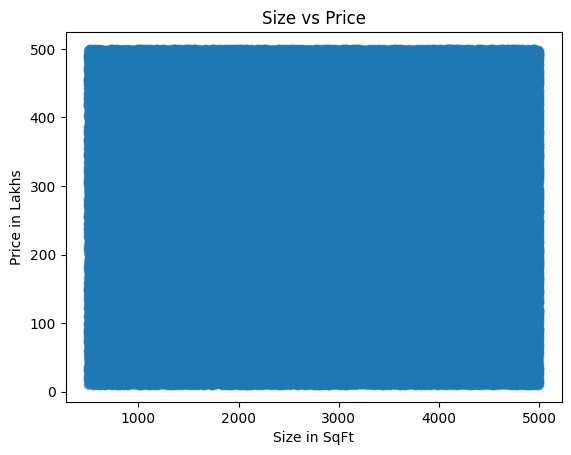

In [30]:
plt.scatter(data['Size_in_SqFt'], data['Price_in_Lakhs'], alpha=0.3)
plt.title("Size vs Price")
plt.xlabel("Size in SqFt")
plt.ylabel("Price in Lakhs")
plt.show()

In [31]:
data.corr(numeric_only=True)

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,1.000000,-0.001718,-0.002293,-0.001636,-0.001344,0.002734,-0.000214,0.003382,-0.002734,-0.001203,0.001429
BHK,-0.001718,1.000000,-0.001033,-0.000980,0.001174,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162
Size_in_SqFt,-0.002293,-0.001033,1.000000,-0.002529,-0.614533,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695
Price_in_Lakhs,-0.001636,-0.000980,-0.002529,1.000000,0.555625,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769
Price_per_SqFt,-0.001344,0.001174,-0.614533,0.555625,1.000000,-0.001212,-0.001906,0.004175,0.001212,-0.000094,-0.000145
Year_Built,0.002734,0.000917,0.004135,0.002714,-0.001212,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719
Floor_No,-0.000214,0.001263,-0.002775,-0.001719,-0.001906,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428
Total_Floors,0.003382,-0.002862,-0.003451,0.001283,0.004175,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867
Age_of_Property,-0.002734,-0.000917,-0.004135,-0.002714,0.001212,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719
Nearby_Schools,-0.001203,-0.000762,0.001966,0.000155,-0.000094,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246


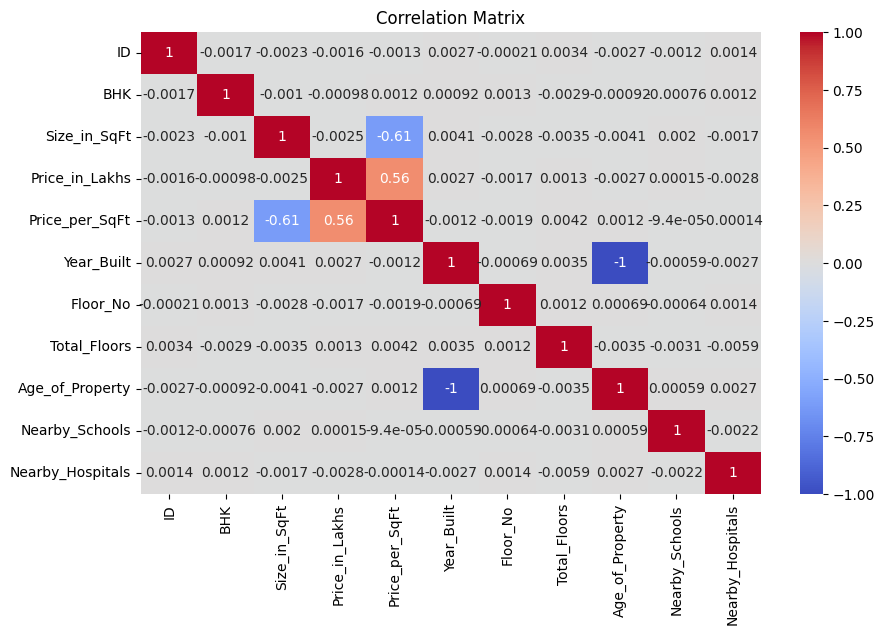

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [33]:
data.corr(numeric_only=True)['Price_in_Lakhs'].sort_values(ascending=False)

Price_in_Lakhs      1.000000
Price_per_SqFt      0.555625
Year_Built          0.002714
Total_Floors        0.001283
Nearby_Schools      0.000155
BHK                -0.000980
ID                 -0.001636
Floor_No           -0.001719
Size_in_SqFt       -0.002529
Age_of_Property    -0.002714
Nearby_Hospitals   -0.002769
Name: Price_in_Lakhs, dtype: float64

In [34]:
data['Property_Type'].value_counts()

Property_Type
Villa                83744
Independent House    83300
Apartment            82956
Name: count, dtype: int64

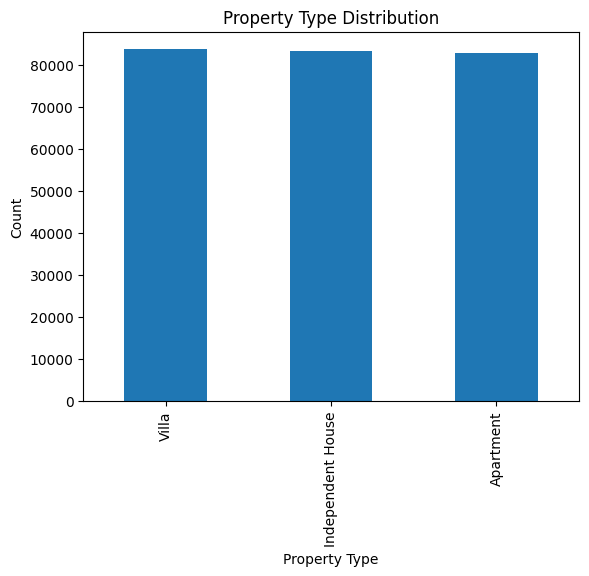

In [35]:
data['Property_Type'].value_counts().plot(kind='bar')
plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.show()

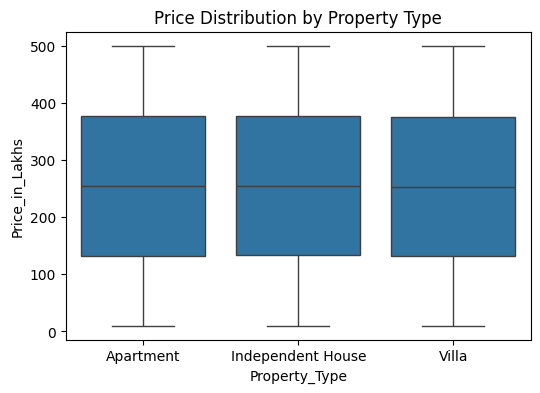

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Property_Type', y='Price_in_Lakhs', data=data)
plt.title("Price Distribution by Property Type")
plt.show()

In [37]:
data.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(10)

City
Bangalore     258.456639
Surat         258.080467
Kochi         257.415221
Gaya          257.053391
Mangalore     256.920925
Dehradun      256.890115
Mysore        256.848172
Chennai       256.830172
Hyderabad     256.594051
Coimbatore    256.504745
Name: Price_in_Lakhs, dtype: float64

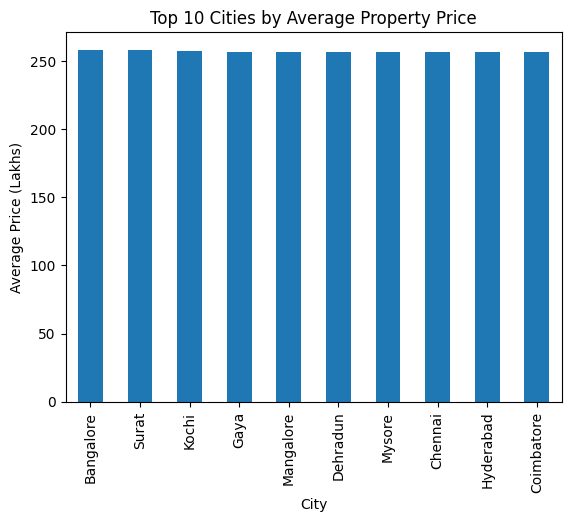

In [38]:
data.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Cities by Average Property Price")
plt.xlabel("City")
plt.ylabel("Average Price (Lakhs)")
plt.show()

In [39]:
data.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [40]:
data['Good_Investment'] = data['Price_in_Lakhs'] < data['Price_in_Lakhs'].median()


In [41]:
data_model = data.copy()
data_model = data_model.drop(columns=['ID', 'State', 'Locality'])
data_model.head()

,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,...,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,Good_Investment
0,Chennai,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,...,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,False
1,Pune,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,...,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,True
2,Ludhiana,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,...,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,True
3,Jodhpur,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,...,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,False
4,Jaipur,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,...,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,True


In [42]:
data_model = pd.get_dummies(data_model, drop_first=True)
data_model.head()

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,...,"Amenities_Pool, Playground, Gym, Clubhouse","Amenities_Pool, Playground, Gym, Clubhouse, Garden","Amenities_Pool, Playground, Gym, Garden","Amenities_Pool, Playground, Gym, Garden, Clubhouse",Facing_North,Facing_South,Facing_West,Owner_Type_Builder,Owner_Type_Owner,Availability_Status_Under_Construction
0,1,4740,489.76,0.10,1990,22,1,35,10,3,...,False,False,False,False,False,False,True,False,True,False
1,3,2364,195.52,0.08,2008,21,20,17,8,1,...,False,False,False,False,True,False,False,True,False,True
2,2,3642,183.79,0.05,1997,19,27,28,9,8,...,False,False,False,False,False,True,False,False,False,False
3,2,2741,300.29,0.11,1991,21,26,34,5,7,...,False,False,False,False,True,False,False,True,False,False
4,4,4823,182.90,0.04,2002,3,2,23,4,9,...,False,False,False,False,False,False,False,True,False,False


In [43]:
X = data_model.drop(columns=['Price_in_Lakhs', 'Good_Investment'])
y = data_model['Price_in_Lakhs']

X.shape, y.shape

((250000, 388), (250000,))

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((200000, 388), (50000, 388))

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [49]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)],
    "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,R2,MAE,RMSE
1,Random Forest,0.996039,6.906494,8.885920
0,Linear Regression,0.489662,81.159654,100.865454


In [50]:
from sklearn.ensemble import RandomForestClassifier

X_class = data_model.drop(columns=['Price_in_Lakhs', 'Good_Investment'])
y_class = data_model['Good_Investment']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(random_state=42)
clf.fit(Xc_train, yc_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)],
    "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,R2,MAE,RMSE
1,Random Forest,0.996039,6.906494,8.885920
0,Linear Regression,0.489662,81.159654,100.865454


In [52]:
from sklearn.ensemble import RandomForestClassifier

X_class = data_model.drop(columns=['Price_in_Lakhs', 'Good_Investment'])
y_class = data_model['Good_Investment']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(random_state=42)
clf.fit(Xc_train, yc_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
import joblib

In [54]:
joblib.dump(rf, "real_estate_rf_model.pkl")
joblib.dump(clf, "investment_classifier.pkl")

# IMPORTANT: save columns separately
joblib.dump(X.columns, "model_columns.pkl")
joblib.dump(X_class.columns, "classifier_columns.pkl")

['classifier_columns.pkl']

In [55]:
price_model = joblib.load("real_estate_rf_model.pkl")
model_columns = joblib.load("model_columns.pkl")

input_data = pd.DataFrame(columns=model_columns)
input_data.loc[0] = 0

input_data.at[0, "Size_in_SqFt"] = 1200
input_data.at[0, "BHK"] = 2
input_data.at[0, "Price_per_SqFt"] = 8000

price_pred = price_model.predict(input_data)[0]
print("Predicted Price:", price_pred)

Predicted Price: 494.35192520333794


In [56]:
investment_model = joblib.load("investment_classifier.pkl")
classifier_columns = joblib.load("classifier_columns.pkl")

input_class = pd.DataFrame(columns=classifier_columns)
input_class.loc[0] = 0

input_class.at[0, "Size_in_SqFt"] = 1200
input_class.at[0, "BHK"] = 2
input_class.at[0, "Price_per_SqFt"] = 8000

invest_pred = investment_model.predict(input_class)[0]
print("Good Investment:", invest_pred)

Good Investment: False


In [57]:
print("🔹 Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

🔹 Linear Regression
R2: 0.489662308083744
MAE: 81.15965441075838
RMSE: 100.8654543602746


In [58]:
print("\n🌳 Random Forest")
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


🌳 Random Forest
R2: 0.9960392492311385
MAE: 6.906494316757602
RMSE: 8.885919698386523


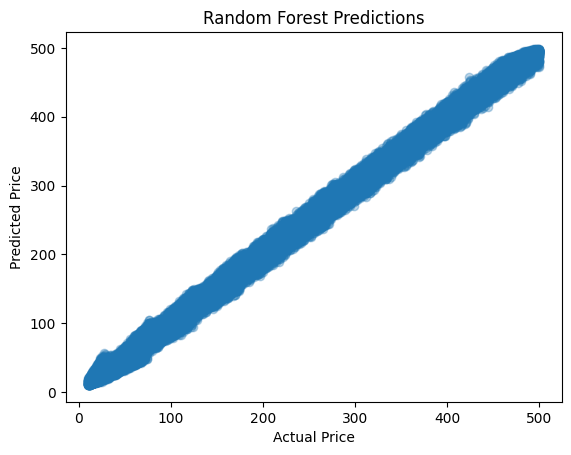

In [59]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions")
plt.show()

In [60]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.489662,81.159654,100.865454
1,Random Forest,0.996039,6.906494,8.885920


In [61]:
results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
1,Random Forest,0.996039,6.906494,8.885920
0,Linear Regression,0.489662,81.159654,100.865454


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Create classification data
X_class = data_model.drop(columns=['Price_in_Lakhs', 'Good_Investment'])
y_class = data_model['Good_Investment']

# Split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(Xc_train, yc_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
import joblib

# Save models
joblib.dump(rf, "real_estate_rf_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")
joblib.dump(clf, "investment_classifier.pkl")

['investment_classifier.pkl']

In [64]:
import joblib

price_model = joblib.load("real_estate_rf_model.pkl")
model_columns = joblib.load("model_columns.pkl")

# Optional (if you trained it)
try:
    investment_model = joblib.load("investment_classifier.pkl")
    print("Investment model loaded ✅")
except:
    investment_model = None
    print("No investment model found ⚠️")

Investment model loaded ✅


In [65]:
import pandas as pd

input_data = pd.DataFrame(columns=model_columns)
input_data.loc[0] = 0

# Fill sample values
if "Size_in_SqFt" in input_data.columns:
    input_data.at[0, "Size_in_SqFt"] = 1200

if "BHK" in input_data.columns:
    input_data.at[0, "BHK"] = 2

if "Price_per_SqFt" in input_data.columns:
    input_data.at[0, "Price_per_SqFt"] = 8000

input_data.head()


,BHK,Size_in_SqFt,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,City_Amritsar,...,"Amenities_Pool, Playground, Gym, Clubhouse","Amenities_Pool, Playground, Gym, Clubhouse, Garden","Amenities_Pool, Playground, Gym, Garden","Amenities_Pool, Playground, Gym, Garden, Clubhouse",Facing_North,Facing_South,Facing_West,Owner_Type_Builder,Owner_Type_Owner,Availability_Status_Under_Construction
0,2,1200,8000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [66]:
price_pred = price_model.predict(input_data)[0]
print("Predicted Price:", price_pred)

Predicted Price: 494.35192520333794


In [67]:
if investment_model is not None:
    invest_pred = investment_model.predict(input_data)[0]
    print("Good Investment:", invest_pred)

Good Investment: False


In [68]:
!python -m pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
%%writefile PropPredict_Pro.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import plotly
import plotly.express as px

# -----------------------------
# Page Config
# -----------------------------
st.set_page_config(page_title="PropPredict Pro", layout="wide")

# -----------------------------
# Load Models
# -----------------------------
price_model = joblib.load("real_estate_rf_model.pkl")
model_columns = joblib.load("model_columns.pkl")

try:
    investment_model = joblib.load("investment_classifier.pkl")
    classifier_columns = joblib.load("classifier_columns.pkl")
except:
    investment_model = None

# -----------------------------
# City Coordinates
# -----------------------------
city_coords = {
    "Bangalore": (12.9716, 77.5946),
    "Chennai": (13.0827, 80.2707),
    "Mumbai": (19.0760, 72.8777),
    "Delhi": (28.7041, 77.1025),
    "Hyderabad": (17.3850, 78.4867)
}

# -----------------------------
# Title
# -----------------------------
st.title("🏠 PropPredict Pro")
st.markdown("### AI Real Estate Price & Investment Advisor")

st.markdown("---")

# -----------------------------
# Sidebar Inputs
# -----------------------------
st.sidebar.header("📥 Property Inputs")

size = st.sidebar.slider("Size (SqFt)", 500, 5000, 1200)
bhk = st.sidebar.selectbox("BHK", [1, 2, 3, 4, 5])
price_per_sqft = st.sidebar.slider("Price per SqFt", 1000, 20000, 8000)

property_type = st.sidebar.selectbox(
    "Property Type",
    ["Apartment", "Villa", "Independent House"]
)

furnishing = st.sidebar.selectbox(
    "Furnishing",
    ["Furnished", "Semi-Furnished", "Unfurnished"]
)

city = st.sidebar.selectbox(
    "City",
    list(city_coords.keys())
)

# -----------------------------
# Predict Button
# -----------------------------
if st.sidebar.button("🚀 Predict"):

    # -----------------------------
    # PRICE INPUT
    # -----------------------------
    input_data = pd.DataFrame(columns=model_columns)
    input_data.loc[0] = 0

    input_data["Size_in_SqFt"] = size
    input_data["BHK"] = bhk
    input_data["Price_per_SqFt"] = price_per_sqft

    # Dropdown mapping
    prop_col = f"Property_Type_{property_type}"
    furn_col = f"Furnishing_{furnishing}"
    city_col = f"City_{city}"

    for col in [prop_col, furn_col, city_col]:
        if col in input_data.columns:
            input_data[col] = 1

    # -----------------------------
    # PRICE PREDICTION
    # -----------------------------
    price_pred = price_model.predict(input_data)[0]

    # -----------------------------
    # DISPLAY METRICS
    # -----------------------------
    st.markdown("## 📊 Results")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("💰 Predicted Price", f"{price_pred:.2f} Lakhs")

    with col2:
        manual = size * price_per_sqft / 100000
        st.metric("📌 Manual Estimate", f"{manual:.2f} Lakhs")

    with col3:
        if investment_model is not None:
            input_class = pd.DataFrame(columns=classifier_columns)
            input_class.loc[0] = 0

            input_class["Size_in_SqFt"] = size
            input_class["BHK"] = bhk
            input_class["Price_per_SqFt"] = price_per_sqft

            for col in [prop_col, furn_col, city_col]:
                if col in input_class.columns:
                    input_class[col] = 1

            prob = investment_model.predict_proba(input_class)[0][1]
            score = int(prob * 100)

            st.metric("🎯 Investment Score", f"{score}/100")

            if score > 70:
                st.success("🔥 Excellent Investment")
            elif score > 50:
                st.info("👍 Moderate Investment")
            else:
                st.warning("⚠️ Risky Investment")

    st.markdown("---")

    # -----------------------------
    # 🗺️ INTERACTIVE MAP (Plotly)
    # -----------------------------
    st.subheader("🗺️ Location Insight")

    lat, lon = city_coords[city]

    # Create nearby points for better visualization
    df_map = pd.DataFrame({
        "lat": lat + np.random.randn(20) * 0.02,
        "lon": lon + np.random.randn(20) * 0.02,
        "price": np.random.randint(50, 500, 20)
    })

    fig = px.scatter_mapbox(
        df_map,
        lat="lat",
        lon="lon",
        size="price",
        color="price",
        color_continuous_scale="viridis",
        zoom=10,
        height=500
    )

    fig.update_layout(mapbox_style="open-street-map")
    st.plotly_chart(fig)

    st.markdown("---")

    # -----------------------------
    # Insight
    # -----------------------------
    st.subheader("📈 Insight")

    st.info(
        "Predictions are based on property size, location, furnishing, and type. "
        "Map shows nearby simulated listings to visualize market density."
    )

Writing PropPredict_Pro.py


In [71]:
!streamlit run PropPredict_Pro.py

^C
